# A look at the NN architecture

This notebook studies an empirical choice of a neural network architecture for the CVA learning procedure.

The objective is not to identify a globally optimal architecture. Since in the full backward algorithm, a distinct neural network is trained at each pricing date and the architecture analysis below should be interpreted as a local diagnostic experiment.

In [1]:
import os
import sys
sys.path.append(os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

from simulation.simulation import compute_fixing_window_size
from products.irs.gpu import calibrate_swap_rate_at_par
from nn_regressor import Regressor
from utils import simulate_and_label, plot_train_val_curves
import warnings
from numba.core.errors import NumbaPerformanceWarning
warnings.filterwarnings("ignore", category=NumbaPerformanceWarning)

/opt/python/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# keeping same params and setup as NMC for direct comparison
# time discretization grid
dT = 0.1
num_substeps = 5
dt = dT / num_substeps
T_horizon = 10.0
num_steps_total = round(T_horizon / dT)

# Risk factors parameters 
# Vasicek short rate (a, b, sigma)
# CIR default intensity (k, theta, xi)
a, b, sigma = 0.3, 0.03, 0.01
k, theta, xi = 0.5, 0.015, 0.01
rho = 0.0
diff_params = (a, b, sigma, k, theta, xi)
r_0, gamma_0 = 0.01, 0.015
# swaps ptf
np.random.seed(0)

num_irs = 500
reset_freq = 0.5

# bank ptf direction bias
prop_pay_fixed = 0.75  # asset heavy
notional = 10000. * (np.random.choice((-1, 1), num_irs, p=(1 - prop_pay_fixed, prop_pay_fixed)) * np.random.choice(range(1, 11), num_irs))

at_par = False   # if true the mtm=0 at t_0 else fixed swap_rate 

irs = []
for i in range(num_irs):
    trade = {
        'first_reset': reset_freq,
        'reset_freq':  reset_freq,
        'num_resets':  int(np.random.randint(6, 21)),
        'notional':    float(notional[i]),
        'swap_rate':   float(np.random.uniform(0.005, 0.05))  # (course case study), random ITM/OTM
    }
    if at_par:
        trade['swap_rate'] = float(
            calibrate_swap_rate_at_par(trade, r_0, a, b, sigma))
    irs.append(trade)

max_maturity = max(s['num_resets'] for s in irs) * reset_freq

print(f"portfolio: {num_irs} interest rate swaps")
print(f"  - {prop_pay_fixed:.0%} pay fixed, {1-prop_pay_fixed:.0%} receive fixed")
print(f"  - priced at par: {at_par}")
print(f"  - max maturity: {max_maturity:.1f}y")

fixing_window_size = compute_fixing_window_size(irs, dt, dT)

portfolio: 500 interest rate swaps
  - 75% pay fixed, 25% receive fixed
  - priced at par: False
  - max maturity: 10.0y


The architecture study below is performed at the representative intermediate date $t = 5y$ which is chosen (midpoint simulation) for diagnostic purposes only.
Initial setup is given by 2 hidden layers × 32 units, ReLU with Softplus output, Kaiming init, Adam lr=1e-3, batch 256, 150 epochs, no early stopping. We start by checking that this baseline converges cleanly before sweeping anything.

Training and validation use independent path sets simulated with distinct seeds and potentially distinct number of simulated paths.
The validation MSE reported below is an out-of-sample estimate. 

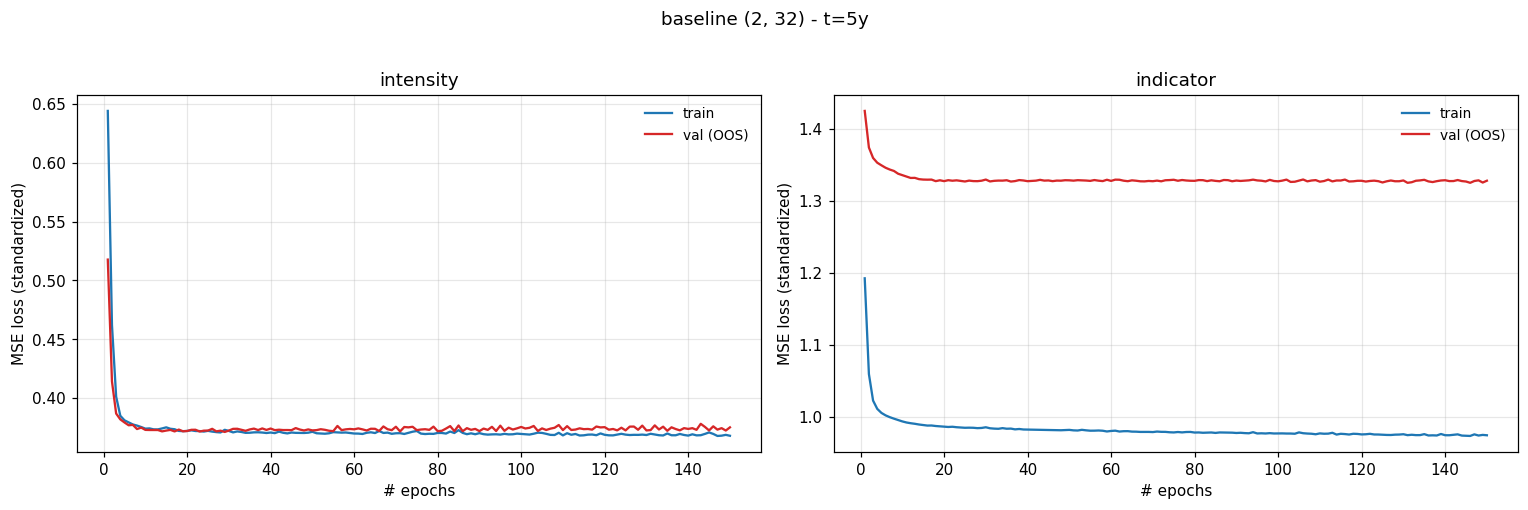

In [3]:
num_outer_paths_tr = 4096
num_outer_paths_val = 1024 # OOS : out-of-sample

t_step = int(5.0 / dT)

def train_baseline(formulation):
    #independent training paths
    feats_tr, labels_tr = simulate_and_label( 
        num_paths=num_outer_paths_tr, seed=42, formulation=formulation,
        num_steps_total=num_steps_total, num_substeps=num_substeps,
        dt=dt, dT=dT, fixing_window_size=fixing_window_size,
        r_0=r_0, gamma_0=gamma_0, diff_params=diff_params, rho=rho, irs=irs,
    )
    # independent oos paths
    feats_oos, labels_oos = simulate_and_label(
        num_paths=num_outer_paths_val, seed=123, formulation=formulation,
        num_steps_total=num_steps_total, num_substeps=num_substeps,
        dt=dt, dT=dT, fixing_window_size=fixing_window_size,
        r_0=r_0, gamma_0=gamma_0, diff_params=diff_params, rho=rho, irs=irs,
    )
    reg = Regressor(
        input_dim=3, hidden_units=32, num_hidden_layers=2,
        lr=1e-3, num_epochs=150, batch_size=256,
        early_stop=False, device='cuda', seed=0, verbose=False,
    )
    reg.train(feats_tr[t_step], labels_tr[t_step],
              feats_oos[t_step], labels_oos[t_step])
    return reg.history

hist_int = train_baseline('intensity')
hist_ind = train_baseline('indicator')

plot_train_val_curves(
    histories=[hist_int, hist_ind],
    titles=['intensity', 'indicator'],
    suptitle='baseline (2, 32) - t=5y',
    inset={'xlim': (20, 80), 'ylim': (0.25, 0.45)},
)

The intensity-based formulation MSE converges with a stable train/val gap. The indicator-based MSE is very unstable across different simulation and training schemes beyond the one shown in the figure above, a point also highlighted in the course.
In the following we focus on the intensity-based formulation and search for a suitable architecture.

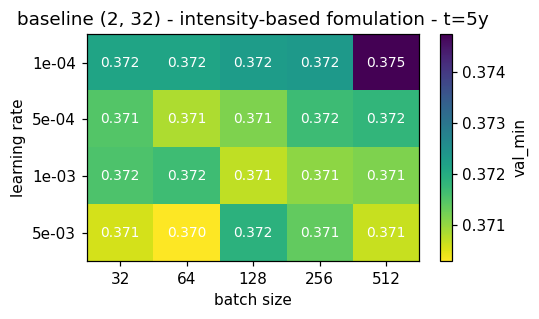

In [5]:
# We fix the architecture at (2, 32) and do a grid search Adam's lr + batch size (avoid bottleneck at the default values)
feats_tr, labels_tr = simulate_and_label(
    num_paths=num_outer_paths_tr, seed=42, formulation='intensity',
    num_steps_total=num_steps_total, num_substeps=num_substeps,
    dt=dt, dT=dT, fixing_window_size=fixing_window_size,
    r_0=r_0, gamma_0=gamma_0, diff_params=diff_params, rho=rho, irs=irs,
)
feats_oos, labels_oos = simulate_and_label(
    num_paths=num_outer_paths_val, seed=123, formulation='intensity',
    num_steps_total=num_steps_total, num_substeps=num_substeps,
    dt=dt, dT=dT, fixing_window_size=fixing_window_size,
    r_0=r_0, gamma_0=gamma_0, diff_params=diff_params, rho=rho, irs=irs,
)
X_tr, y_tr = feats_tr[t_step], labels_tr[t_step]
X_oos, y_oos = feats_oos[t_step], labels_oos[t_step]

lr_grid = [1e-4, 5e-4, 1e-3, 5e-3]
batch_grid = [32, 64, 128, 256, 512]
val_grid = np.zeros((len(lr_grid), len(batch_grid)))

for i, lr in enumerate(lr_grid):
    for j, bs in enumerate(batch_grid):
        reg = Regressor(
            input_dim=3, hidden_units=32, num_hidden_layers=2,
            lr=lr, num_epochs=150, batch_size=bs,
            early_stop=False, device='cuda', seed=0, verbose=False,
        )
        reg.train(X_tr, y_tr, X_oos, y_oos)
        val_grid[i, j] = np.array(reg.history['val_loss']).min()

# heatmap
fig, ax = plt.subplots(figsize=(5, 3), dpi=110)
im = ax.imshow(val_grid, cmap='viridis_r', aspect='auto')
ax.set_xticks(range(len(batch_grid)))
ax.set_xticklabels(batch_grid)
ax.set_yticks(range(len(lr_grid)))
ax.set_yticklabels([f'{lr:.0e}' for lr in lr_grid])
ax.set_xlabel('batch size')
ax.set_ylabel('learning rate')
ax.set_title('baseline (2, 32) - intensity-based fomulation - t=5y')
for i in range(len(lr_grid)):
    for j in range(len(batch_grid)):
        ax.text(j, i, f'{val_grid[i,j]:.3f}', ha='center', va='center', color='white', fontsize=9)
plt.colorbar(im, ax=ax, label='val_min')
plt.tight_layout()
plt.show()

The validation MSE varies by less than 1% across the grid.
Ddefault lr/batch do not have a meaningful impact on performance.

/tmp/ipykernel_838457/2397939161.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


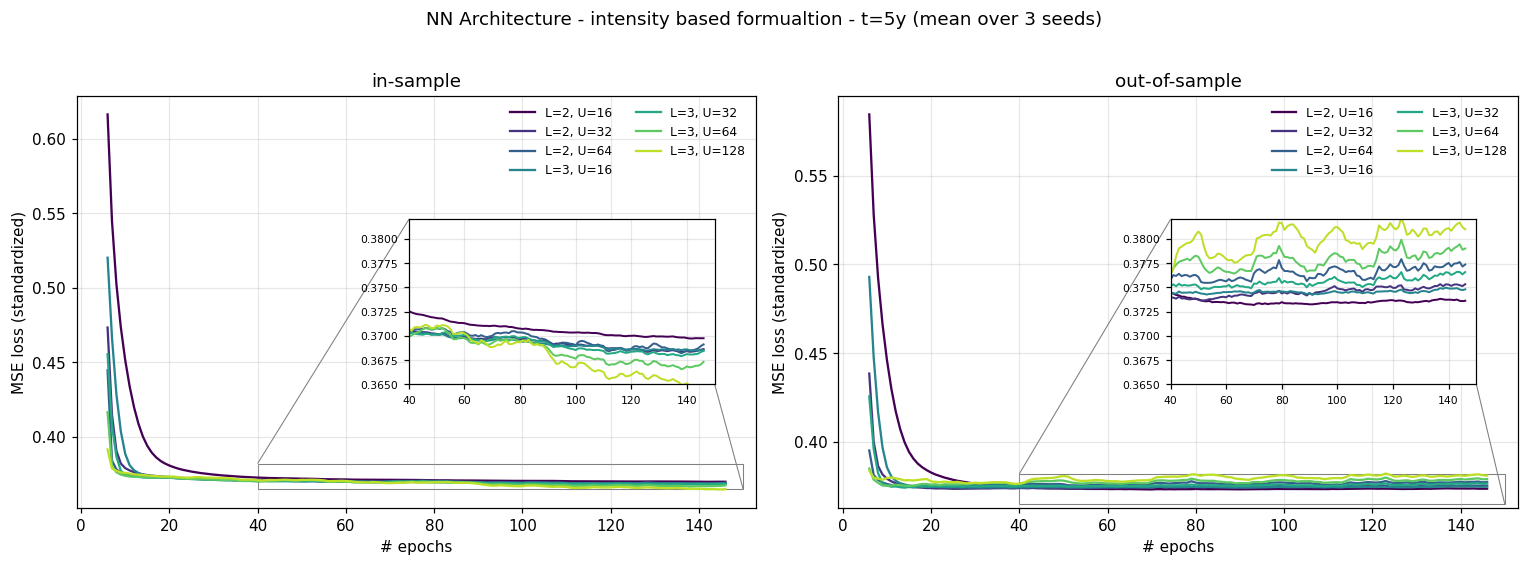

In [ ]:
# candidate NN archis
archis = [(2, 16), (2, 32), (2, 64), (3, 16), (3, 32), (3, 64), (3, 128)]
seeds = [0, 1, 2] # mean over 3 diffs seeds to marginalize out initialization variance + isolate the architecture's effect

feats_tr, labels_tr = simulate_and_label(
    num_paths=num_outer_paths_tr, seed=42, formulation='intensity',
    num_steps_total=num_steps_total, num_substeps=num_substeps,
    dt=dt, dT=dT, fixing_window_size=fixing_window_size,
    r_0=r_0, gamma_0=gamma_0, diff_params=diff_params, rho=rho, irs=irs,
)
feats_oos, labels_oos = simulate_and_label(
    num_paths=num_outer_paths_val, seed=123, formulation='intensity',
    num_steps_total=num_steps_total, num_substeps=num_substeps,
    dt=dt, dT=dT, fixing_window_size=fixing_window_size,
    r_0=r_0, gamma_0=gamma_0, diff_params=diff_params, rho=rho, irs=irs,
)
X_tr, y_tr = feats_tr[t_step], labels_tr[t_step]
X_oos, y_oos = feats_oos[t_step], labels_oos[t_step]

results = {a: {'train': [], 'val': []} for a in archis}
for archi in archis:
    n_layers, n_units = archi
    for sd in seeds:
        reg = Regressor(
            input_dim=3, hidden_units=n_units, num_hidden_layers=n_layers,
            lr=1e-3, num_epochs=150, batch_size=256,
            early_stop=False, device='cuda', seed=sd, verbose=False,
        )
        reg.train(X_tr, y_tr, X_oos, y_oos)
        results[archi]['train'].append(np.array(reg.history['train_loss']))
        results[archi]['val'].append(np.array(reg.history['val_loss']))

def smooth(arr, w=10):
    # function for moving average smoothing
    # helper function only for plotting purposes only to make curves visually readable
    return np.convolve(arr, np.ones(w)/w, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=110)
colors = plt.cm.viridis(np.linspace(0, 0.9, len(archis)))

for ax, key, title in zip(axes, ['train', 'val'], ['in-sample', 'out-of-sample']):
    for archi, col in zip(archis, colors):
        curves = np.stack(results[archi][key])
        mean = smooth(curves.mean(axis=0), 10)
        epochs = np.arange(1, len(mean) + 1) + 5
        ax.plot(epochs, mean, color=col, lw=1.5, label=f'L={archi[0]}, U={archi[1]}')
    ax.set_xlabel('# epochs')
    ax.set_ylabel('MSE loss (standardized)')
    ax.set_title(title)
    ax.legend(frameon=False, ncol=2, fontsize=8, loc='upper right')
    ax.grid(alpha=0.3)

    axins = inset_axes(ax, width="45%", height="40%", loc='center right',
                       bbox_to_anchor=(-0.05, 0.0, 1, 1), bbox_transform=ax.transAxes)
    for archi, col in zip(archis, colors):
        curves = np.stack(results[archi][key])
        mean = smooth(curves.mean(axis=0), 10)
        epochs = np.arange(1, len(mean) + 1) + 5
        axins.plot(epochs, mean, color=col, lw=1.3)
    axins.set_xlim(40, 150)
    axins.set_ylim(0.365, 0.382)
    axins.tick_params(labelsize=7)
    axins.grid(alpha=0.3)
    mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5", lw=0.7)

fig.suptitle('NN Architecture - intensity based formualtion - t=5y (mean over 3 seeds)', y=1.02)
plt.tight_layout()
plt.show()

The in-sample MSE decreases as the number of layers/units (capacity) grows. 
On the out-of-sample side smaller architectures continue to improve and stabilise around $~0.365$.
Larger ones reach their minimum near epoch $50$ before increasing again and overfit.
One would retain $N_\text{layers}=2$ and $N_\text{units}=16$ as it achieves the lowest out-of-sample error around $0.48$, which is not negligible in itself but will validate against nested Monte Carlo benchmarks too in the validation step. 
It also remains stable across the $150$ epochs and is a parsimonious choice.
This grid gives an indicative ranking only on the single pricing date $t=5y$. The actual training pipeline includes the backward pass over all pricing dates with transfer learning mechanism between consecutive time steps. The final validation of the retained architecture is conducted against nested Monte Carlo benchmarks.